In [21]:
print("Рубежный контроль 1. Росстегаев Денис. ИБМ3-65Б. Вариант 18, задача 3, датасет 2")

Рубежный контроль 1. Росстегаев Денис. ИБМ3-65Б. Вариант 18, задача 3, датасет 2


In [22]:
from sklearn.datasets import load_wine
import pandas as pd
import matplotlib.pyplot as plt

# загружаем датасет
wine = load_wine(as_frame=True)
df = wine.frame

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [23]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["alcohol_scaled"] = scaler.fit_transform(df[["alcohol"]])

df[["alcohol", "alcohol_scaled"]].head()

,alcohol,alcohol_scaled
0,14.23,1.518613
1,13.20,0.246290
2,13.16,0.196879
3,14.37,1.691550
4,13.24,0.295700


In [25]:
print("Масштабирование выполнено с использованием метода StandardScaler.\n"
"Данный метод преобразует данные по формуле:\n"
"z = (x - среднее) / стандартное отклонение\n"
"Это необходимо, так как признаки в датасете имеют разные масштабы.\n"
"Без нормализации признаки с большими значениями могут сильнее влиять на модель.\n")

Масштабирование выполнено с использованием метода StandardScaler.
Данный метод преобразует данные по формуле:
z = (x - среднее) / стандартное отклонение
Это необходимо, так как признаки в датасете имеют разные масштабы.
Без нормализации признаки с большими значениями могут сильнее влиять на модель.



In [26]:
df["alcohol_category"] = pd.cut(
    df["alcohol"],
    bins=[0, 12.5, 13.5, 20],
    labels=["low", "medium", "high"]
)

df[["alcohol", "alcohol_category"]].head()

,alcohol,alcohol_category
0,14.23,high
1,13.20,medium
2,13.16,medium
3,14.37,high
4,13.24,medium


In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["alcohol_label"] = le.fit_transform(df["alcohol_category"])

df[["alcohol_category", "alcohol_label"]].head()

,alcohol_category,alcohol_label
0,high,0
1,medium,2
2,medium,2
3,high,0
4,medium,2


In [28]:
print("Label Encoding — это метод преобразования категориальных данных в числовые.\nКаждой категории присваивается число (например: low=0, medium=1, high=2).\nНедостаток метода — создаётся ложный порядок между категориями.")

Label Encoding — это метод преобразования категориальных данных в числовые.
Каждой категории присваивается число (например: low=0, medium=1, high=2).
Недостаток метода — создаётся ложный порядок между категориями.


In [30]:
df_onehot = pd.get_dummies(df["alcohol_category"], prefix="alcohol").astype(int)

df = pd.concat([df, df_onehot], axis=1)

df[["alcohol_category", "alcohol_low", "alcohol_medium", "alcohol_high"]].head()

,alcohol_category,alcohol_low,alcohol_low,alcohol_medium,alcohol_medium,alcohol_high,alcohol_high
0,high,False,0,False,0,True,1
1,medium,False,0,True,1,False,0
2,medium,False,0,True,1,False,0
3,high,False,0,False,0,True,1
4,medium,False,0,True,1,False,0


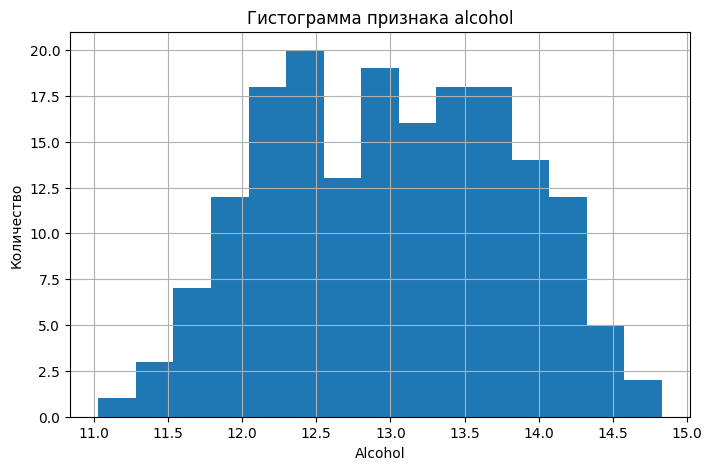

In [31]:
plt.figure(figsize=(8,5))
plt.hist(df["alcohol"], bins=15)
plt.title("Гистограмма признака alcohol")
plt.xlabel("Alcohol")
plt.ylabel("Количество")
plt.grid()

plt.show()

In [32]:
print("""
В ходе выполнения задания были использованы следующие методы предобработки данных.

1. Масштабирование данных (StandardScaler)

Для числового признака alcohol был применён метод StandardScaler.
Он преобразует данные по формуле:
z = (x - среднее) / стандартное отклонение.

Данный метод был выбран, потому что признаки в датасете имеют разные масштабы.
Например, признак proline принимает значения до 1600, тогда как alcohol — около 11–14.
Без масштабирования признаки с большими значениями могут сильнее влиять на модель.
StandardScaler приводит данные к единому масштабу (среднее ≈ 0, стандартное отклонение ≈ 1).

2. Создание категориального признака

Так как в исходном наборе данных отсутствовали категориальные признаки,
был искусственно создан признак alcohol_category на основе признака alcohol
путём разбиения на интервалы: низкий, средний и высокий уровень.

3. Label Encoding

Для преобразования категориального признака в числовой был использован метод Label Encoding.
Он заменяет категории числами (например: low, medium, high → 0, 1, 2).

Метод выбран, потому что он прост в реализации и позволяет быстро преобразовать данные.
Однако его недостаток — создаётся ложный порядок между категориями.

4. One-Hot Encoding

Также был применён метод One-Hot Encoding, при котором для каждой категории
создаётся отдельный бинарный столбец (0 или 1).

Данный метод выбран, потому что он не создаёт ложного порядка между категориями
и более корректно представляет категориальные данные.

Вывод:

Были использованы методы масштабирования и кодирования категориальных признаков.
Наиболее корректным методом кодирования является One-Hot Encoding,
так как он не искажает данные.
""")


В ходе выполнения задания были использованы следующие методы предобработки данных.

1. Масштабирование данных (StandardScaler)

Для числового признака alcohol был применён метод StandardScaler.
Он преобразует данные по формуле:
z = (x - среднее) / стандартное отклонение.

Данный метод был выбран, потому что признаки в датасете имеют разные масштабы.
Например, признак proline принимает значения до 1600, тогда как alcohol — около 11–14.
Без масштабирования признаки с большими значениями могут сильнее влиять на модель.
StandardScaler приводит данные к единому масштабу (среднее ≈ 0, стандартное отклонение ≈ 1).

2. Создание категориального признака

Так как в исходном наборе данных отсутствовали категориальные признаки,
был искусственно создан признак alcohol_category на основе признака alcohol
путём разбиения на интервалы: низкий, средний и высокий уровень.

3. Label Encoding

Для преобразования категориального признака в числовой был использован метод Label Encoding.
Он заменяет категор